In [1]:
import os
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    KFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.decomposition import PCA
from sklearn.feature_selection import RFECV
from sklearn.inspection import permutation_importance

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    GradientBoostingClassifier
)

from sklearn.svm import SVC, SVR

In [2]:
os.makedirs("milk_models", exist_ok=True)
os.makedirs("milk_outputs", exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


In [3]:
df = pd.read_csv("Final_milk_dataset.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (275, 22)


,SampleID,Brand,WaterPercent,A410,A435,A460,A485,A510,A535,B560,...,B645,B680,B705,C730,C760,C810,C860,C900,C940,Condition
0,S-001,AMUL,0,629.97,294.43,1429.77,348.03,562.22,318.30,334.63,...,255.86,250.02,46.10,30.34,27.42,196.95,452.36,41.90,16.31,normal
1,S-002,AMUL,0,602.25,269.66,1351.87,352.28,568.54,281.09,277.21,...,328.25,230.62,37.04,27.23,22.58,155.85,345.31,40.67,16.31,cloth
2,S-003,AMUL,0,613.17,309.68,1697.67,324.20,691.37,372.72,203.60,...,262.93,260.80,35.07,35.00,27.42,148.14,329.20,36.35,16.31,normal
3,S-004,AMUL,0,645.93,315.39,1696.72,325.90,691.37,374.79,205.17,...,262.93,260.80,35.46,35.00,27.42,147.28,330.35,36.35,16.31,normal
4,S-005,AMUL,0,612.33,303.96,1553.27,348.88,663.99,376.86,248.50,...,287.89,259.72,40.98,35.00,28.23,156.70,379.84,38.20,17.21,cloth


In [4]:
df.columns = [c.strip() for c in df.columns]

print("Columns:")
print(df.columns.tolist())
print()
print(df.info())
print()
print(df.isna().sum())

Columns:
['SampleID', 'Brand', 'WaterPercent', 'A410', 'A435', 'A460', 'A485', 'A510', 'A535', 'B560', 'B585', 'B610', 'B645', 'B680', 'B705', 'C730', 'C760', 'C810', 'C860', 'C900', 'C940', 'Condition']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 22 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SampleID      275 non-null    object 
 1   Brand         275 non-null    object 
 2   WaterPercent  275 non-null    int64  
 3   A410          275 non-null    float64
 4   A435          275 non-null    float64
 5   A460          275 non-null    float64
 6   A485          275 non-null    float64
 7   A510          275 non-null    float64
 8   A535          275 non-null    float64
 9   B560          275 non-null    float64
 10  B585          275 non-null    float64
 11  B610          275 non-null    float64
 12  B645          275 non-null    float64
 13  B680          275 non-null    float64
 1

In [5]:
spectral_cols = [
    "A410", "A435", "A460", "A485", "A510", "A535",
    "B560", "B585", "B610", "B645", "B680", "B705",
    "C730", "C760", "C810", "C860", "C900", "C940"
]

required_cols = ["SampleID", "Brand", "WaterPercent", "Condition"] + spectral_cols

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

print("All required columns are present.")

All required columns are present.


In [6]:
df["Brand"] = df["Brand"].astype(str).str.strip().str.upper()
df["Condition"] = df["Condition"].astype(str).str.strip().str.lower()

for c in spectral_cols + ["WaterPercent"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=spectral_cols + ["Brand", "WaterPercent", "Condition"]).copy()
df = df[df["WaterPercent"].between(0, 50)].copy()

valid_conditions = ["normal", "cloth"]
df = df[df["Condition"].isin(valid_conditions)].copy()

print("Shape after cleaning:", df.shape)
df.head()

Shape after cleaning: (275, 22)


,SampleID,Brand,WaterPercent,A410,A435,A460,A485,A510,A535,B560,...,B645,B680,B705,C730,C760,C810,C860,C900,C940,Condition
0,S-001,AMUL,0,629.97,294.43,1429.77,348.03,562.22,318.30,334.63,...,255.86,250.02,46.10,30.34,27.42,196.95,452.36,41.90,16.31,normal
1,S-002,AMUL,0,602.25,269.66,1351.87,352.28,568.54,281.09,277.21,...,328.25,230.62,37.04,27.23,22.58,155.85,345.31,40.67,16.31,cloth
2,S-003,AMUL,0,613.17,309.68,1697.67,324.20,691.37,372.72,203.60,...,262.93,260.80,35.07,35.00,27.42,148.14,329.20,36.35,16.31,normal
3,S-004,AMUL,0,645.93,315.39,1696.72,325.90,691.37,374.79,205.17,...,262.93,260.80,35.46,35.00,27.42,147.28,330.35,36.35,16.31,normal
4,S-005,AMUL,0,612.33,303.96,1553.27,348.88,663.99,376.86,248.50,...,287.89,259.72,40.98,35.00,28.23,156.70,379.84,38.20,17.21,cloth


In [7]:
def get_status_from_water(w):
    if w <= 5:
        return "PURE"
    elif w <= 15:
        return "LOW_ADULTERATION"
    elif w <= 30:
        return "MODERATE_ADULTERATION"
    else:
        return "HIGH_ADULTERATION"

def get_quality_score(w):
    score = 100 - (1.8 * w)
    return max(0, min(100, score))

df["StatusDerived"] = df["WaterPercent"].apply(get_status_from_water)
df["QualityScoreDerived"] = df["WaterPercent"].apply(get_quality_score)

df[["Brand", "WaterPercent", "Condition", "StatusDerived", "QualityScoreDerived"]].head()

,Brand,WaterPercent,Condition,StatusDerived,QualityScoreDerived
0,AMUL,0,normal,PURE,100.0
1,AMUL,0,cloth,PURE,100.0
2,AMUL,0,normal,PURE,100.0
3,AMUL,0,normal,PURE,100.0
4,AMUL,0,cloth,PURE,100.0


In [8]:
print("Brand counts:")
print(df["Brand"].value_counts())
print()
print("WaterPercent counts:")
print(df["WaterPercent"].value_counts().sort_index())
print()
print("Condition counts:")
print(df["Condition"].value_counts())

Brand counts:
Brand
AMUL               55
COUNTRY DELIGHT    55
GO                 55
METRO              55
MOTHER DAIRY       55
Name: count, dtype: int64

WaterPercent counts:
WaterPercent
0     25
5     25
10    25
15    25
20    25
25    25
30    25
35    25
40    25
45    25
50    25
Name: count, dtype: int64

Condition counts:
Condition
normal    165
cloth     110
Name: count, dtype: int64


In [9]:
df["row_std"] = df[spectral_cols].std(axis=1)

threshold = df["row_std"].quantile(0.95)
df_clean = df[df["row_std"] < threshold].copy()

print("Original shape:", df.shape)
print("After removing top 5% noisy rows:", df_clean.shape)

Original shape: (275, 25)
After removing top 5% noisy rows: (261, 25)


In [10]:
df_model = df_clean[df_clean["Condition"] == "normal"].copy()

print("Modeling shape:", df_model.shape)
print(df_model["Condition"].value_counts())

Modeling shape: (155, 25)
Condition
normal    155
Name: count, dtype: int64


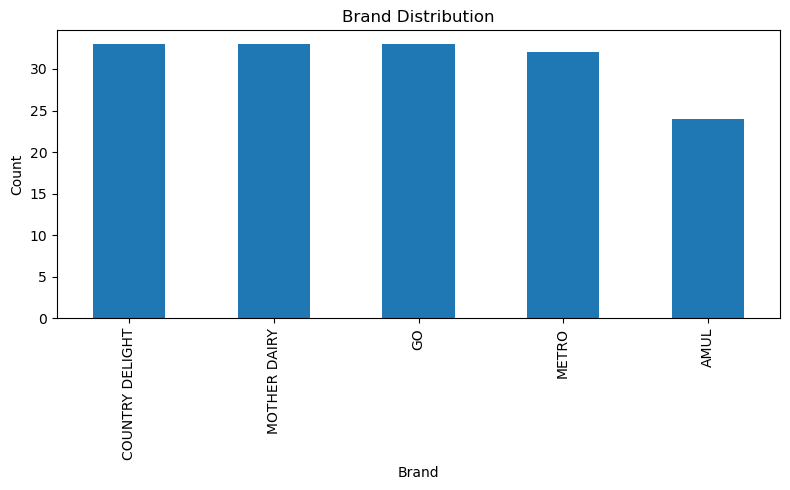

In [11]:
plt.figure(figsize=(8, 5))
df_model["Brand"].value_counts().plot(kind="bar")
plt.title("Brand Distribution")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("milk_outputs/plot1_brand_distribution.png", dpi=200)
plt.show()

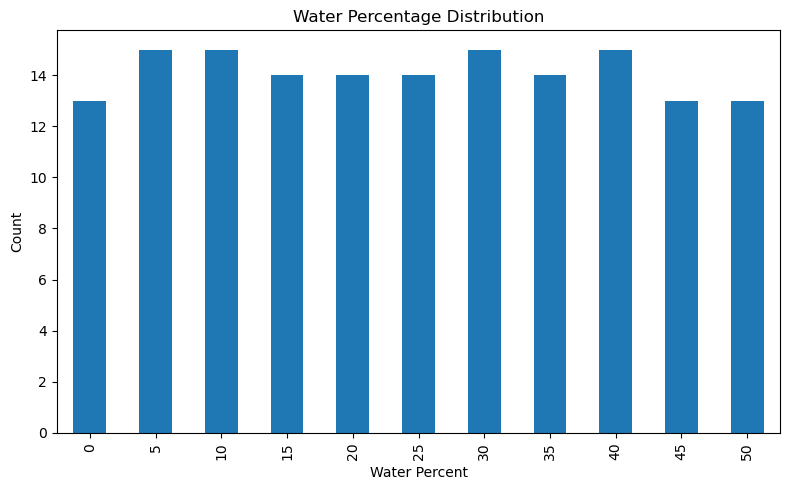

In [12]:
plt.figure(figsize=(8, 5))
df_model["WaterPercent"].value_counts().sort_index().plot(kind="bar")
plt.title("Water Percentage Distribution")
plt.xlabel("Water Percent")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("milk_outputs/plot2_water_distribution.png", dpi=200)
plt.show()

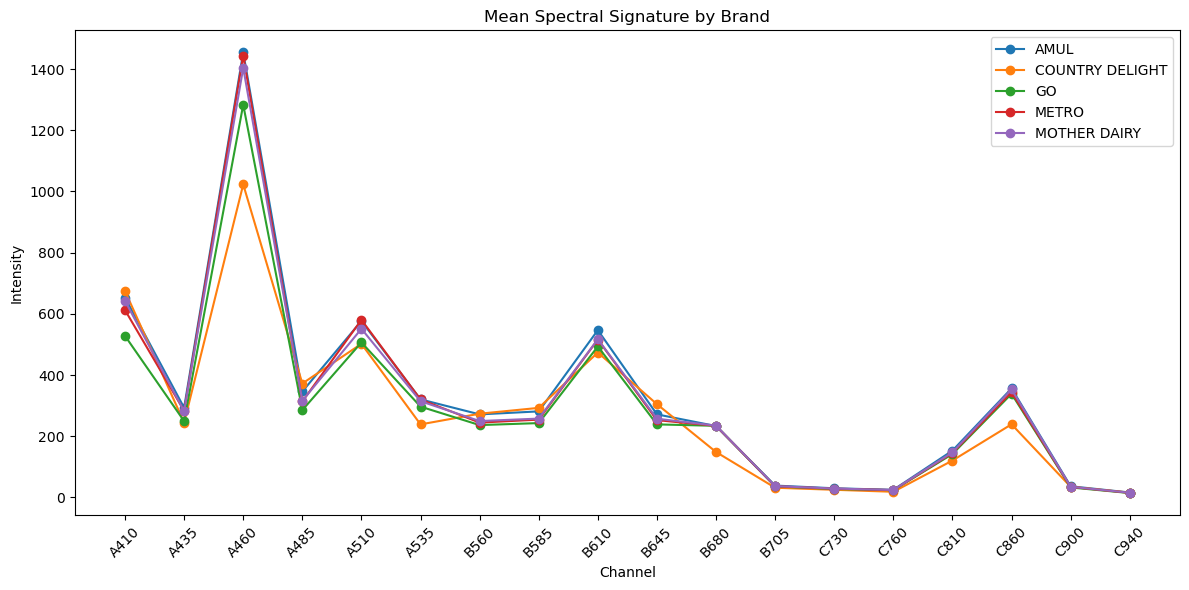

In [13]:
plt.figure(figsize=(12, 6))

for brand in sorted(df_model["Brand"].unique()):
    mean_spec = df_model[df_model["Brand"] == brand][spectral_cols].mean()
    plt.plot(spectral_cols, mean_spec.values, marker="o", label=brand)

plt.title("Mean Spectral Signature by Brand")
plt.xlabel("Channel")
plt.ylabel("Intensity")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("milk_outputs/plot3_mean_spectrum_by_brand.png", dpi=200)
plt.show()

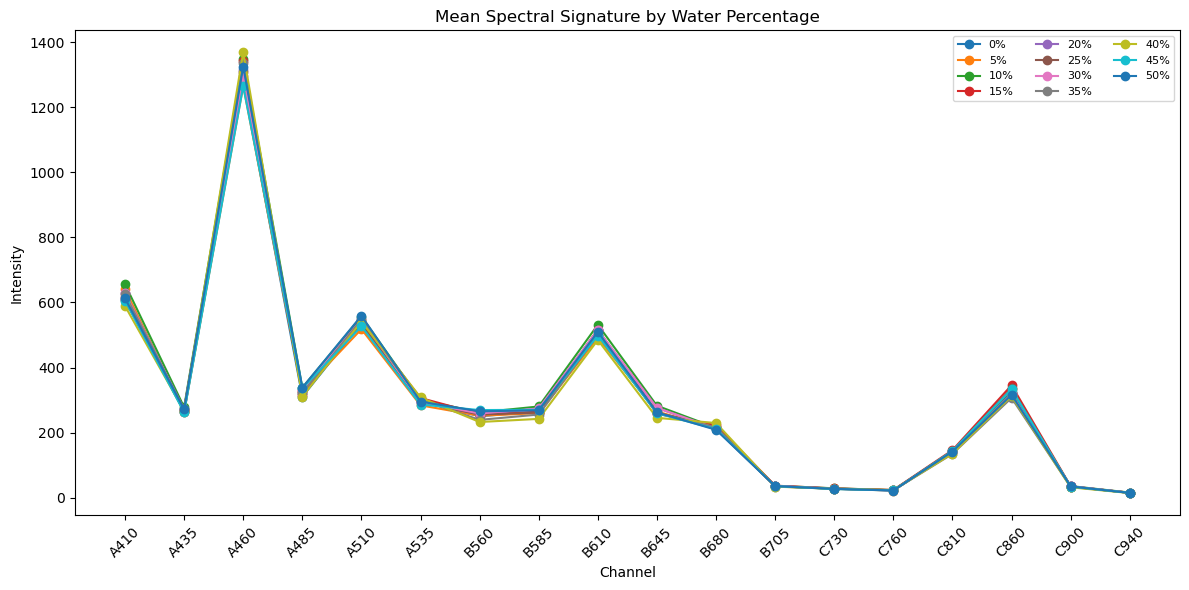

In [14]:
plt.figure(figsize=(12, 6))

for wp in sorted(df_model["WaterPercent"].unique()):
    mean_spec = df_model[df_model["WaterPercent"] == wp][spectral_cols].mean()
    plt.plot(spectral_cols, mean_spec.values, marker="o", label=f"{wp}%")

plt.title("Mean Spectral Signature by Water Percentage")
plt.xlabel("Channel")
plt.ylabel("Intensity")
plt.xticks(rotation=45)
plt.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.savefig("milk_outputs/plot4_mean_spectrum_by_water.png", dpi=200)
plt.show()

In [15]:
def add_engineered_features(data):
    x = data.copy()
    eps = 1e-8

    visible_cols = ["A410", "A435", "A460", "A485", "A510", "A535", "B560", "B585", "B610"]
    nir_cols = ["B645", "B680", "B705", "C730", "C760", "C810", "C860", "C900", "C940"]

    x["SpecSum"] = x[spectral_cols].sum(axis=1)

    for c in spectral_cols:
        x[f"{c}_norm"] = x[c] / (x["SpecSum"] + eps)

    x["R_410_940"] = x["A410"] / (x["C940"] + eps)
    x["R_435_900"] = x["A435"] / (x["C900"] + eps)
    x["R_460_860"] = x["A460"] / (x["C860"] + eps)
    x["R_510_760"] = x["A510"] / (x["C760"] + eps)
    x["R_560_810"] = x["B560"] / (x["C810"] + eps)
    x["R_610_940"] = x["B610"] / (x["C940"] + eps)

    x["VisibleMean"] = x[visible_cols].mean(axis=1)
    x["NIRMean"] = x[nir_cols].mean(axis=1)
    x["VisibleNIRRatio"] = x["VisibleMean"] / (x["NIRMean"] + eps)

    x["VisibleSum"] = x[visible_cols].sum(axis=1)
    x["NIRSum"] = x[nir_cols].sum(axis=1)

    x["Diff_410_435"] = x["A410"] - x["A435"]
    x["Diff_435_460"] = x["A435"] - x["A460"]
    x["Diff_760_810"] = x["C760"] - x["C810"]
    x["Diff_860_940"] = x["C860"] - x["C940"]

    x["Log_410"] = np.log1p(x["A410"])
    x["Log_940"] = np.log1p(x["C940"])

    x["SpecMax"] = x[spectral_cols].max(axis=1)
    x["SpecMin"] = x[spectral_cols].min(axis=1)
    x["SpecStd"] = x[spectral_cols].std(axis=1)
    x["SpecRange"] = x["SpecMax"] - x["SpecMin"]

    x["Slope_410_940"] = (x["C940"] - x["A410"]) / (940 - 410)
    x["Slope_435_860"] = (x["C860"] - x["A435"]) / (860 - 435)
    x["Slope_510_760"] = (x["C760"] - x["A510"]) / (760 - 510)

    return x

df_feat = add_engineered_features(df_model)
print("Feature engineered shape:", df_feat.shape)
df_feat.head()

Feature engineered shape: (155, 68)


,SampleID,Brand,WaterPercent,A410,A435,A460,A485,A510,A535,B560,...,Diff_860_940,Log_410,Log_940,SpecMax,SpecMin,SpecStd,SpecRange,Slope_410_940,Slope_435_860,Slope_510_760
0,S-001,AMUL,0,629.97,294.43,1429.77,348.03,562.22,318.30,334.63,...,436.05,6.447258,2.851284,1429.77,16.31,335.977587,1413.46,-1.157849,0.371600,-2.13920
5,S-006,AMUL,5,737.49,315.39,1467.77,392.27,616.97,317.61,273.55,...,321.69,6.604608,2.996732,1467.77,19.02,352.583207,1448.75,-1.355604,0.059576,-2.36464
7,S-008,AMUL,5,600.57,242.98,1140.01,374.40,506.77,281.78,326.80,...,348.57,6.399543,2.851284,1140.01,16.31,275.659307,1123.70,-1.102377,0.286824,-1.93996
8,S-009,AMUL,5,596.37,241.07,1134.31,373.55,505.36,281.78,327.33,...,352.02,6.392537,2.851284,1134.31,16.31,274.259281,1118.00,-1.094453,0.299435,-1.93432
10,S-011,AMUL,10,763.52,308.72,1422.17,388.02,595.21,301.76,279.30,...,323.74,6.639248,2.950735,1422.17,18.12,344.415815,1404.05,-1.406415,0.077976,-2.28404


In [16]:
normalized_cols = [f"{c}_norm" for c in spectral_cols]

engineered_cols = [
    "SpecSum",
    "R_410_940",
    "R_435_900",
    "R_460_860",
    "R_510_760",
    "R_560_810",
    "R_610_940",
    "VisibleMean",
    "NIRMean",
    "VisibleNIRRatio",
    "VisibleSum",
    "NIRSum",
    "Diff_410_435",
    "Diff_435_460",
    "Diff_760_810",
    "Diff_860_940",
    "Log_410",
    "Log_940",
    "SpecMax",
    "SpecMin",
    "SpecStd",
    "SpecRange",
    "Slope_410_940",
    "Slope_435_860",
    "Slope_510_760"
]

feature_cols = spectral_cols + normalized_cols + engineered_cols

print("Total feature count:", len(feature_cols))

Total feature count: 61


In [17]:
X_brand = df_feat[feature_cols].copy()
y_brand = df_feat["Brand"].copy()

brand_encoder = LabelEncoder()
y_brand_enc = brand_encoder.fit_transform(y_brand)

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_brand,
    y_brand_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_brand_enc
)

print("Brand train shape:", Xb_train.shape)
print("Brand test shape:", Xb_test.shape)
print("Brand classes:", list(brand_encoder.classes_))

Brand train shape: (124, 61)
Brand test shape: (31, 61)
Brand classes: ['AMUL', 'COUNTRY DELIGHT', 'GO', 'METRO', 'MOTHER DAIRY']


In [18]:
brand_numeric_cols = X_brand.columns.tolist()

brand_preprocessor_scaled = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), brand_numeric_cols)
])

brand_preprocessor_unscaled = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ]), brand_numeric_cols)
])

print("Brand preprocessors ready.")

Brand preprocessors ready.


In [19]:
brand_models = {
    "rf_clf": Pipeline([
        ("prep", brand_preprocessor_unscaled),
        ("model", RandomForestClassifier(
            n_estimators=400,
            random_state=42,
            class_weight="balanced"
        ))
    ]),
    "et_clf": Pipeline([
        ("prep", brand_preprocessor_unscaled),
        ("model", ExtraTreesClassifier(
            n_estimators=500,
            random_state=42,
            class_weight="balanced"
        ))
    ]),
    "svc_clf": Pipeline([
        ("prep", brand_preprocessor_scaled),
        ("model", SVC(
            kernel="rbf",
            probability=True,
            class_weight="balanced",
            random_state=42
        ))
    ]),
    "gb_clf": Pipeline([
        ("prep", brand_preprocessor_unscaled),
        ("model", GradientBoostingClassifier(random_state=42))
    ])
}

In [20]:
def evaluate_brand_models(models, X_data, y_data):
    print("===== BRAND MODEL SELECTION =====")
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = {}

    for name, model in models.items():
        cv_scores = cross_val_score(model, X_data, y_data, cv=skf, scoring="accuracy")
        scores[name] = cv_scores.mean()
        print(f"{name}: CV Accuracy = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    best_name = max(scores, key=scores.get)
    print(f"\nBest baseline brand model: {best_name}")
    return best_name, scores

best_brand_baseline_name, brand_baseline_scores = evaluate_brand_models(
    brand_models, Xb_train, yb_train
)

best_brand_baseline_pipeline = brand_models[best_brand_baseline_name]

===== BRAND MODEL SELECTION =====
rf_clf: CV Accuracy = 0.8867 ± 0.0481
et_clf: CV Accuracy = 0.8950 ± 0.0602
svc_clf: CV Accuracy = 0.8867 ± 0.0321
gb_clf: CV Accuracy = 0.8793 ± 0.0350

Best baseline brand model: et_clf


In [21]:
best_brand_baseline_pipeline.fit(Xb_train, yb_train)
brand_baseline_pred = best_brand_baseline_pipeline.predict(Xb_test)

baseline_acc = accuracy_score(yb_test, brand_baseline_pred)
baseline_f1 = f1_score(yb_test, brand_baseline_pred, average="weighted")

print("Baseline Brand Accuracy:", round(baseline_acc, 4))
print("Baseline Brand Weighted F1:", round(baseline_f1, 4))
print()
print(classification_report(yb_test, brand_baseline_pred, target_names=brand_encoder.classes_))

Baseline Brand Accuracy: 0.871
Baseline Brand Weighted F1: 0.8645

                 precision    recall  f1-score   support

           AMUL       1.00      0.60      0.75         5
COUNTRY DELIGHT       1.00      1.00      1.00         6
             GO       0.78      1.00      0.88         7
          METRO       0.86      1.00      0.92         6
   MOTHER DAIRY       0.83      0.71      0.77         7

       accuracy                           0.87        31
      macro avg       0.89      0.86      0.86        31
   weighted avg       0.88      0.87      0.86        31



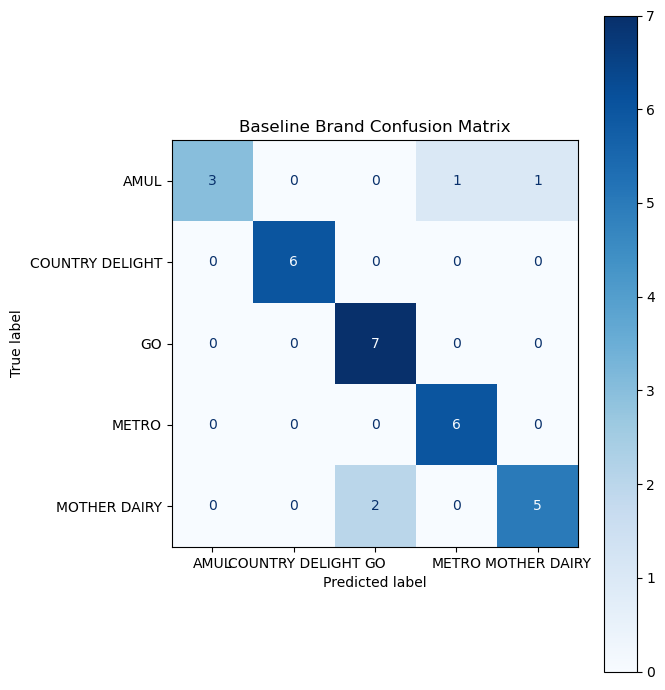

In [22]:
cm = confusion_matrix(yb_test, brand_baseline_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=brand_encoder.classes_)

fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Baseline Brand Confusion Matrix")
plt.tight_layout()
plt.savefig("milk_outputs/brand_baseline_confusion_matrix.png", dpi=200)
plt.show()

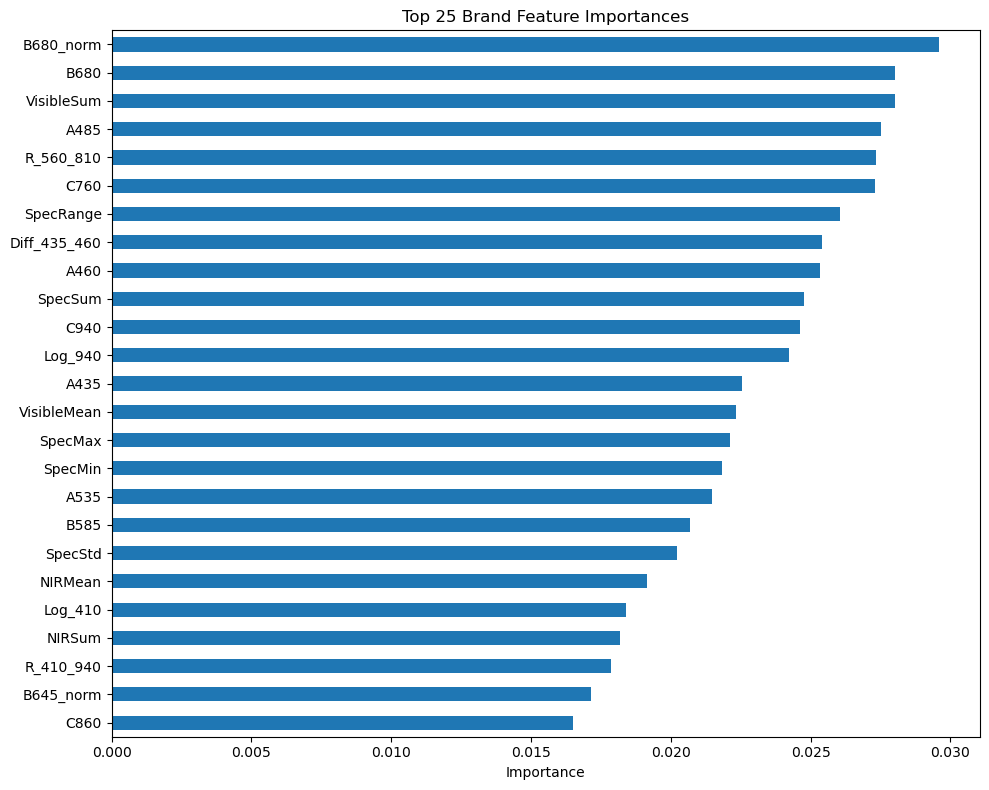

B680_norm       0.029578
B680            0.028035
VisibleSum      0.028029
A485            0.027501
R_560_810       0.027324
C760            0.027314
SpecRange       0.026061
Diff_435_460    0.025398
A460            0.025334
SpecSum         0.024762
C940            0.024632
Log_940         0.024213
A435            0.022536
VisibleMean     0.022339
SpecMax         0.022115
SpecMin         0.021830
A535            0.021480
B585            0.020678
SpecStd         0.020217
NIRMean         0.019141
Log_410         0.018399
NIRSum          0.018184
R_410_940       0.017844
B645_norm       0.017130
C860            0.016489
dtype: float64

In [23]:
Xb_train_proc = brand_preprocessor_unscaled.fit_transform(Xb_train)
Xb_test_proc = brand_preprocessor_unscaled.transform(Xb_test)

et_feature_model = ExtraTreesClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced"
)
et_feature_model.fit(Xb_train_proc, yb_train)

feature_importances = pd.Series(et_feature_model.feature_importances_, index=X_brand.columns)
feature_importances = feature_importances.sort_values(ascending=False)

top_25_features = feature_importances.head(25)

plt.figure(figsize=(10, 8))
top_25_features.sort_values().plot(kind="barh")
plt.title("Top 25 Brand Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("milk_outputs/brand_top25_feature_importances.png", dpi=200)
plt.show()

top_25_features

In [24]:
top_n = 25
selected_brand_features = feature_importances.head(top_n).index.tolist()

print("Selected top features:")
print(selected_brand_features)

Selected top features:
['B680_norm', 'B680', 'VisibleSum', 'A485', 'R_560_810', 'C760', 'SpecRange', 'Diff_435_460', 'A460', 'SpecSum', 'C940', 'Log_940', 'A435', 'VisibleMean', 'SpecMax', 'SpecMin', 'A535', 'B585', 'SpecStd', 'NIRMean', 'Log_410', 'NIRSum', 'R_410_940', 'B645_norm', 'C860']


In [25]:
X_brand_reduced = df_feat[selected_brand_features].copy()

Xbr_train, Xbr_test, ybr_train, ybr_test = train_test_split(
    X_brand_reduced,
    y_brand_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_brand_enc
)

print("Reduced train shape:", Xbr_train.shape)
print("Reduced test shape:", Xbr_test.shape)

Reduced train shape: (124, 25)
Reduced test shape: (31, 25)


In [26]:
reduced_numeric_cols = X_brand_reduced.columns.tolist()

brand_preprocessor_scaled_reduced = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), reduced_numeric_cols)
])

brand_preprocessor_unscaled_reduced = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ]), reduced_numeric_cols)
])

In [27]:
brand_models_reduced = {
    "rf_clf": Pipeline([
        ("prep", brand_preprocessor_unscaled_reduced),
        ("model", RandomForestClassifier(
            n_estimators=500,
            random_state=42,
            class_weight="balanced"
        ))
    ]),
    "et_clf": Pipeline([
        ("prep", brand_preprocessor_unscaled_reduced),
        ("model", ExtraTreesClassifier(
            n_estimators=700,
            random_state=42,
            class_weight="balanced"
        ))
    ]),
    "svc_clf": Pipeline([
        ("prep", brand_preprocessor_scaled_reduced),
        ("model", SVC(
            kernel="rbf",
            probability=True,
            class_weight="balanced",
            random_state=42
        ))
    ])
}

In [28]:
best_brand_reduced_name, brand_reduced_scores = evaluate_brand_models(
    brand_models_reduced,
    Xbr_train,
    ybr_train
)

best_brand_reduced_pipeline = brand_models_reduced[best_brand_reduced_name]

===== BRAND MODEL SELECTION =====
rf_clf: CV Accuracy = 0.8783 ± 0.0590
et_clf: CV Accuracy = 0.8870 ± 0.0533
svc_clf: CV Accuracy = 0.8143 ± 0.0416

Best baseline brand model: et_clf


In [29]:
best_brand_reduced_pipeline.fit(Xbr_train, ybr_train)
brand_reduced_pred = best_brand_reduced_pipeline.predict(Xbr_test)

reduced_acc = accuracy_score(ybr_test, brand_reduced_pred)
reduced_f1 = f1_score(ybr_test, brand_reduced_pred, average="weighted")

print("Reduced-Feature Brand Accuracy:", round(reduced_acc, 4))
print("Reduced-Feature Brand Weighted F1:", round(reduced_f1, 4))
print()
print(classification_report(ybr_test, brand_reduced_pred, target_names=brand_encoder.classes_))

Reduced-Feature Brand Accuracy: 0.871
Reduced-Feature Brand Weighted F1: 0.8667

                 precision    recall  f1-score   support

           AMUL       0.75      0.60      0.67         5
COUNTRY DELIGHT       1.00      1.00      1.00         6
             GO       0.88      1.00      0.93         7
          METRO       0.83      0.83      0.83         6
   MOTHER DAIRY       0.86      0.86      0.86         7

       accuracy                           0.87        31
      macro avg       0.86      0.86      0.86        31
   weighted avg       0.87      0.87      0.87        31



In [30]:
rfecv_brand_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rfecv_brand = RFECV(
    estimator=rfecv_brand_model,
    step=1,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="accuracy",
    n_jobs=-1
)

rfecv_brand.fit(Xb_train_proc, yb_train)

print("Optimal feature count from RFECV:", rfecv_brand.n_features_)

rfecv_selected_features = [
    fname for fname, keep in zip(X_brand.columns.tolist(), rfecv_brand.support_) if keep
]

print("RFECV selected features:")
print(rfecv_selected_features)

Optimal feature count from RFECV: 37
RFECV selected features:
['A410', 'A435', 'A460', 'A485', 'A535', 'B560', 'B585', 'B610', 'B680', 'C760', 'C810', 'C860', 'C900', 'C940', 'A485_norm', 'B645_norm', 'B680_norm', 'C730_norm', 'C760_norm', 'C940_norm', 'SpecSum', 'R_410_940', 'R_560_810', 'VisibleMean', 'NIRMean', 'VisibleSum', 'NIRSum', 'Diff_410_435', 'Diff_435_460', 'Diff_860_940', 'Log_410', 'Log_940', 'SpecMax', 'SpecMin', 'SpecStd', 'SpecRange', 'Slope_410_940']


In [31]:
X_brand_rfecv = df_feat[rfecv_selected_features].copy()

Xrf_train, Xrf_test, yrf_train, yrf_test = train_test_split(
    X_brand_rfecv,
    y_brand_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_brand_enc
)

print("RFECV train shape:", Xrf_train.shape)
print("RFECV test shape:", Xrf_test.shape)

RFECV train shape: (124, 37)
RFECV test shape: (31, 37)


In [32]:
rfecv_numeric_cols = X_brand_rfecv.columns.tolist()

brand_preprocessor_scaled_rfecv = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), rfecv_numeric_cols)
])

brand_preprocessor_unscaled_rfecv = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ]), rfecv_numeric_cols)
])

brand_models_rfecv = {
    "rf_clf": Pipeline([
        ("prep", brand_preprocessor_unscaled_rfecv),
        ("model", RandomForestClassifier(
            n_estimators=500,
            random_state=42,
            class_weight="balanced"
        ))
    ]),
    "et_clf": Pipeline([
        ("prep", brand_preprocessor_unscaled_rfecv),
        ("model", ExtraTreesClassifier(
            n_estimators=700,
            random_state=42,
            class_weight="balanced"
        ))
    ]),
    "svc_clf": Pipeline([
        ("prep", brand_preprocessor_scaled_rfecv),
        ("model", SVC(
            kernel="rbf",
            probability=True,
            class_weight="balanced",
            random_state=42
        ))
    ])
}

In [33]:
best_brand_rfecv_name, brand_rfecv_scores = evaluate_brand_models(
    brand_models_rfecv,
    Xrf_train,
    yrf_train
)

best_brand_rfecv_pipeline = brand_models_rfecv[best_brand_rfecv_name]

===== BRAND MODEL SELECTION =====
rf_clf: CV Accuracy = 0.8863 ± 0.0613
et_clf: CV Accuracy = 0.8953 ± 0.0540
svc_clf: CV Accuracy = 0.8787 ± 0.0373

Best baseline brand model: et_clf


In [34]:
best_brand_rfecv_pipeline.fit(Xrf_train, yrf_train)
brand_rfecv_pred = best_brand_rfecv_pipeline.predict(Xrf_test)

rfecv_acc = accuracy_score(yrf_test, brand_rfecv_pred)
rfecv_f1 = f1_score(yrf_test, brand_rfecv_pred, average="weighted")

print("RFECV Brand Accuracy:", round(rfecv_acc, 4))
print("RFECV Brand Weighted F1:", round(rfecv_f1, 4))
print()
print(classification_report(yrf_test, brand_rfecv_pred, target_names=brand_encoder.classes_))


RFECV Brand Accuracy: 0.9032
RFECV Brand Weighted F1: 0.8975

                 precision    recall  f1-score   support

           AMUL       1.00      0.60      0.75         5
COUNTRY DELIGHT       1.00      1.00      1.00         6
             GO       0.88      1.00      0.93         7
          METRO       0.86      1.00      0.92         6
   MOTHER DAIRY       0.86      0.86      0.86         7

       accuracy                           0.90        31
      macro avg       0.92      0.89      0.89        31
   weighted avg       0.91      0.90      0.90        31



In [35]:
et_brand_grid = {
    "model__n_estimators": [300, 500, 800],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

et_brand_pipeline = Pipeline([
    ("prep", brand_preprocessor_unscaled_reduced),
    ("model", ExtraTreesClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

brand_search = GridSearchCV(
    estimator=et_brand_pipeline,
    param_grid=et_brand_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

brand_search.fit(Xbr_train, ybr_train)

print("Best params:", brand_search.best_params_)
print("Best CV score:", brand_search.best_score_)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 300}
Best CV score: 0.8870000000000001


In [36]:
best_tuned_brand_pipeline = brand_search.best_estimator_
brand_tuned_pred = best_tuned_brand_pipeline.predict(Xbr_test)

tuned_acc = accuracy_score(ybr_test, brand_tuned_pred)
tuned_f1 = f1_score(ybr_test, brand_tuned_pred, average="weighted")

print("Tuned Brand Accuracy:", round(tuned_acc, 4))
print("Tuned Brand Weighted F1:", round(tuned_f1, 4))
print()
print(classification_report(ybr_test, brand_tuned_pred, target_names=brand_encoder.classes_))

Tuned Brand Accuracy: 0.8387
Tuned Brand Weighted F1: 0.8269

                 precision    recall  f1-score   support

           AMUL       0.67      0.40      0.50         5
COUNTRY DELIGHT       1.00      1.00      1.00         6
             GO       0.88      1.00      0.93         7
          METRO       0.83      0.83      0.83         6
   MOTHER DAIRY       0.75      0.86      0.80         7

       accuracy                           0.84        31
      macro avg       0.82      0.82      0.81        31
   weighted avg       0.83      0.84      0.83        31



In [37]:
comparison = pd.DataFrame({
    "ModelVariant": [
        "Baseline Best",
        "Top-Feature Best",
        "RFECV Best",
        "Tuned Top-Feature"
    ],
    "Accuracy": [
        baseline_acc,
        reduced_acc,
        rfecv_acc,
        tuned_acc
    ],
    "WeightedF1": [
        baseline_f1,
        reduced_f1,
        rfecv_f1,
        tuned_f1
    ]
})

comparison = comparison.sort_values(by="Accuracy", ascending=False)
comparison

,ModelVariant,Accuracy,WeightedF1
2,RFECV Best,0.903226,0.897477
0,Baseline Best,0.870968,0.864454
1,Top-Feature Best,0.870968,0.866667
3,Tuned Top-Feature,0.838710,0.826882


In [38]:
final_brand_pipeline = best_brand_baseline_pipeline
final_brand_feature_mode = "full_feature_set"
final_brand_input_cols = X_brand.columns.tolist()

best_row = comparison.iloc[0]["ModelVariant"]

if best_row == "Baseline Best":
    final_brand_pipeline = best_brand_baseline_pipeline
    final_brand_feature_mode = "full_feature_set"
    final_brand_input_cols = X_brand.columns.tolist()

elif best_row == "Top-Feature Best":
    final_brand_pipeline = best_brand_reduced_pipeline
    final_brand_feature_mode = "top_feature_set"
    final_brand_input_cols = selected_brand_features

elif best_row == "RFECV Best":
    final_brand_pipeline = best_brand_rfecv_pipeline
    final_brand_feature_mode = "rfecv_feature_set"
    final_brand_input_cols = rfecv_selected_features

elif best_row == "Tuned Top-Feature":
    final_brand_pipeline = best_tuned_brand_pipeline
    final_brand_feature_mode = "tuned_top_feature_set"
    final_brand_input_cols = selected_brand_features

print("Final brand model selected:", best_row)
print("Feature mode:", final_brand_feature_mode)
print("Input columns used:", final_brand_input_cols)

Final brand model selected: RFECV Best
Feature mode: rfecv_feature_set
Input columns used: ['A410', 'A435', 'A460', 'A485', 'A535', 'B560', 'B585', 'B610', 'B680', 'C760', 'C810', 'C860', 'C900', 'C940', 'A485_norm', 'B645_norm', 'B680_norm', 'C730_norm', 'C760_norm', 'C940_norm', 'SpecSum', 'R_410_940', 'R_560_810', 'VisibleMean', 'NIRMean', 'VisibleSum', 'NIRSum', 'Diff_410_435', 'Diff_435_460', 'Diff_860_940', 'Log_410', 'Log_940', 'SpecMax', 'SpecMin', 'SpecStd', 'SpecRange', 'Slope_410_940']


In [39]:
joblib.dump(final_brand_pipeline, "milk_models/final_brand_pipeline_optimized.pkl")
joblib.dump(brand_encoder, "milk_models/brand_encoder.pkl")
joblib.dump(final_brand_input_cols, "milk_models/final_brand_input_cols.pkl")

brand_metadata = {
    "brand_classes": list(brand_encoder.classes_),
    "final_brand_feature_mode": final_brand_feature_mode,
    "final_input_feature_count": len(final_brand_input_cols)
}

with open("milk_models/brand_model_metadata.json", "w") as f:
    json.dump(brand_metadata, f, indent=2)

print("Optimized brand model saved.")

Optimized brand model saved.


In [40]:
X_water = df_feat[feature_cols].copy()
y_water = df_feat["WaterPercent"].copy()

Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    X_water,
    y_water,
    test_size=0.2,
    random_state=42
)

print("Water train shape:", Xw_train.shape)
print("Water test shape:", Xw_test.shape)

Water train shape: (124, 61)
Water test shape: (31, 61)


In [41]:
water_numeric_cols = X_water.columns.tolist()

water_preprocessor_scaled = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), water_numeric_cols)
])

water_preprocessor_unscaled = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ]), water_numeric_cols)
])

In [42]:
water_models = {
    "rf_reg": Pipeline([
        ("prep", water_preprocessor_unscaled),
        ("model", RandomForestRegressor(n_estimators=300, random_state=42))
    ]),
    "et_reg": Pipeline([
        ("prep", water_preprocessor_unscaled),
        ("model", ExtraTreesRegressor(n_estimators=500, random_state=42))
    ]),
    "gb_reg": Pipeline([
        ("prep", water_preprocessor_unscaled),
        ("model", GradientBoostingRegressor(random_state=42))
    ]),
    "svr_reg": Pipeline([
        ("prep", water_preprocessor_scaled),
        ("model", SVR(kernel="rbf"))
    ])
}

In [43]:
def evaluate_water_models(models, X_data, y_data):
    print("===== WATER MODEL SELECTION =====")
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = {}

    for name, model in models.items():
        neg_mae = cross_val_score(model, X_data, y_data, cv=kf, scoring="neg_mean_absolute_error")
        mae = -neg_mae.mean()
        scores[name] = mae
        print(f"{name}: CV MAE = {mae:.4f}")

    best_name = min(scores, key=scores.get)
    print(f"\nBest water model: {best_name}")
    return best_name, scores

best_water_name, water_cv_scores = evaluate_water_models(water_models, Xw_train, yw_train)
water_pipeline = water_models[best_water_name]

===== WATER MODEL SELECTION =====
rf_reg: CV MAE = 8.2796
et_reg: CV MAE = 6.7111
gb_reg: CV MAE = 8.2304
svr_reg: CV MAE = 12.6925

Best water model: et_reg


In [44]:
water_pipeline.fit(Xw_train, yw_train)
water_pred = water_pipeline.predict(Xw_test)
water_pred = np.clip(water_pred, 0, 50)

water_mae = mean_absolute_error(yw_test, water_pred)
water_rmse = np.sqrt(mean_squared_error(yw_test, water_pred))
water_r2 = r2_score(yw_test, water_pred)

print("Water MAE:", round(water_mae, 4))
print("Water RMSE:", round(water_rmse, 4))
print("Water R2:", round(water_r2, 4))

Water MAE: 8.2445
Water RMSE: 11.203
Water R2: 0.4724


In [45]:
water_pred_rounded = np.round(water_pred / 5) * 5
water_pred_rounded = np.clip(water_pred_rounded, 0, 50)

rounded_mae = mean_absolute_error(yw_test, water_pred_rounded)
rounded_rmse = np.sqrt(mean_squared_error(yw_test, water_pred_rounded))
rounded_r2 = r2_score(yw_test, water_pred_rounded)

print("Rounded Water MAE:", round(rounded_mae, 4))
print("Rounded Water RMSE:", round(rounded_rmse, 4))
print("Rounded Water R2:", round(rounded_r2, 4))

Rounded Water MAE: 7.7419
Rounded Water RMSE: 10.7763
Rounded Water R2: 0.5118


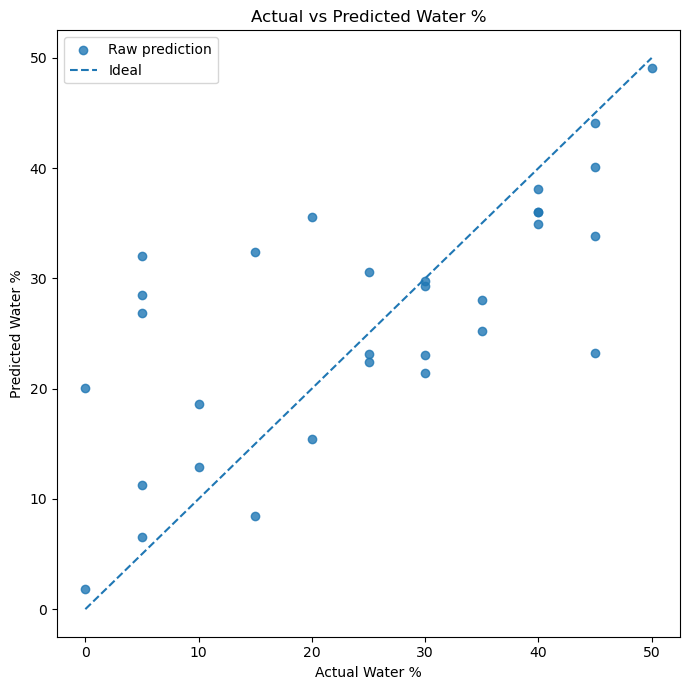

In [46]:
plt.figure(figsize=(7, 7))
plt.scatter(yw_test, water_pred, alpha=0.8, label="Raw prediction")
plt.plot([0, 50], [0, 50], linestyle="--", label="Ideal")
plt.xlabel("Actual Water %")
plt.ylabel("Predicted Water %")
plt.title("Actual vs Predicted Water %")
plt.legend()
plt.tight_layout()
plt.savefig("milk_outputs/plot7_water_actual_vs_predicted.png", dpi=200)
plt.show()

In [47]:
derived_status_pred = [get_status_from_water(w) for w in water_pred_rounded]
true_status = [get_status_from_water(w) for w in yw_test]

derived_status_acc = accuracy_score(true_status, derived_status_pred)
derived_status_f1 = f1_score(true_status, derived_status_pred, average="weighted")

print("Derived Status Accuracy:", round(derived_status_acc, 4))
print("Derived Status Weighted F1:", round(derived_status_f1, 4))
print()
print(classification_report(true_status, derived_status_pred))

Derived Status Accuracy: 0.6129
Derived Status Weighted F1: 0.6113

                       precision    recall  f1-score   support

    HIGH_ADULTERATION       0.89      0.73      0.80        11
     LOW_ADULTERATION       0.50      0.50      0.50         4
MODERATE_ADULTERATION       0.44      0.78      0.56         9
                 PURE       1.00      0.29      0.44         7

             accuracy                           0.61        31
            macro avg       0.71      0.57      0.58        31
         weighted avg       0.73      0.61      0.61        31



In [48]:
water_grid = {
    "model__n_estimators": [300, 500, 800],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5, 10]
}

et_water_pipeline = Pipeline([
    ("prep", water_preprocessor_unscaled),
    ("model", ExtraTreesRegressor(random_state=42))
])

water_search = GridSearchCV(
    estimator=et_water_pipeline,
    param_grid=water_grid,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1,
    verbose=1
)

water_search.fit(Xw_train, yw_train)

print("Best params:", water_search.best_params_)
print("Best CV score:", water_search.best_score_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best params: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 800}
Best CV score: -7.081754166666667


In [49]:
best_tuned_water_pipeline = water_search.best_estimator_

tuned_water_pred = best_tuned_water_pipeline.predict(Xw_test)
tuned_water_pred = np.clip(tuned_water_pred, 0, 50)

tuned_mae = mean_absolute_error(yw_test, tuned_water_pred)
tuned_rmse = np.sqrt(mean_squared_error(yw_test, tuned_water_pred))
tuned_r2 = r2_score(yw_test, tuned_water_pred)

print("Tuned Water MAE:", round(tuned_mae, 4))
print("Tuned Water RMSE:", round(tuned_rmse, 4))
print("Tuned Water R2:", round(tuned_r2, 4))

Tuned Water MAE: 8.2542
Tuned Water RMSE: 11.2054
Tuned Water R2: 0.4722


In [50]:
final_water_pipeline = water_pipeline

if tuned_mae < water_mae:
    final_water_pipeline = best_tuned_water_pipeline
    print("Using tuned water pipeline.")
else:
    print("Keeping original water pipeline.")

Keeping original water pipeline.


In [51]:
final_water_pred = final_water_pipeline.predict(Xw_test)
final_water_pred = np.clip(final_water_pred, 0, 50)

final_water_pred_rounded = np.round(final_water_pred / 5) * 5
final_water_pred_rounded = np.clip(final_water_pred_rounded, 0, 50)

final_mae = mean_absolute_error(yw_test, final_water_pred_rounded)
final_rmse = np.sqrt(mean_squared_error(yw_test, final_water_pred_rounded))
final_r2 = r2_score(yw_test, final_water_pred_rounded)

print("Final Rounded Water MAE:", round(final_mae, 4))
print("Final Rounded Water RMSE:", round(final_rmse, 4))
print("Final Rounded Water R2:", round(final_r2, 4))

Final Rounded Water MAE: 7.7419
Final Rounded Water RMSE: 10.7763
Final Rounded Water R2: 0.5118


In [52]:
joblib.dump(final_water_pipeline, "milk_models/final_water_pipeline.pkl")
joblib.dump(feature_cols, "milk_models/feature_cols.pkl")
joblib.dump(spectral_cols, "milk_models/spectral_cols.pkl")

metadata = {
    "dataset_shape": list(df_model.shape),
    "brands": list(brand_encoder.classes_),
    "brand_feature_mode": final_brand_feature_mode,
    "brand_input_feature_count": len(final_brand_input_cols),
    "water_feature_count": len(feature_cols)
}

with open("milk_models/final_model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Final brand and water models saved.")

Final brand and water models saved.


In [53]:
def predict_milk_sample(raw_channels_dict):
    required = set(spectral_cols)
    if set(raw_channels_dict.keys()) != required:
        missing = required - set(raw_channels_dict.keys())
        extra = set(raw_channels_dict.keys()) - required
        raise ValueError(f"Missing: {missing}, Extra: {extra}")

    # raw sample
    sample = pd.DataFrame([raw_channels_dict])

    # feature engineering
    sample_feat = add_engineered_features(sample)

    # brand prediction uses selected input columns
    brand_input = sample_feat[final_brand_input_cols]
    brand_pred_enc = final_brand_pipeline.predict(brand_input)[0]
    brand_pred = brand_encoder.inverse_transform([brand_pred_enc])[0]

    # water prediction uses full feature columns
    water_input = sample_feat[feature_cols]
    water_pred = float(final_water_pipeline.predict(water_input)[0])
    water_pred = max(0.0, min(50.0, water_pred))

    # snap to nearest 5
    water_pred = round(water_pred / 5) * 5
    water_pred = max(0.0, min(50.0, water_pred))

    uncertainty = 7
    status_pred = get_status_from_water(water_pred)
    quality_score = max(0.0, min(100.0, 100.0 - 1.8 * water_pred))

    return {
        "predictedBrand": brand_pred,
        "waterPercent": water_pred,
        "uncertainty": f"±{uncertainty}%",
        "status": status_pred,
        "qualityScore": round(quality_score, 2)
    }

In [54]:
sample_row = df_feat.iloc[0]
sample_input = {c: float(sample_row[c]) for c in spectral_cols}

result = predict_milk_sample(sample_input)
print(result)

{'predictedBrand': 'AMUL', 'waterPercent': 0.0, 'uncertainty': '±7%', 'status': 'PURE', 'qualityScore': 100.0}


In [55]:
example_payload = {
    "channels": {c: float(df_feat.iloc[0][c]) for c in spectral_cols}
}

with open("milk_outputs/example_payload.json", "w") as f:
    json.dump(example_payload, f, indent=2)

print("Example payload saved.")

Example payload saved.
